# Mendoza Reporta — Fase 4: Fusión Multimodal Lineal

## Objetivo
Evaluar la arquitectura final del sistema, que reemplaza la lógica de competencia "Texto OR Imagen" de las fases anteriores por una fusión colaborativa entre el motor de texto y el filtro visual, sobre los umbrales relajados de la Fase 3.

## Componentes de esta fase
1. **Rescate por texto:** si el filtro visual rechaza un reporte únicamente por `no_problem_detected` (imagen ambigua) y el texto es válido, el reporte no se descarta y pasa a la fusión.
2. **Fusión lineal ponderada:** `score = 0.6 · similitud_texto + 0.4 · probabilidad_CLIP`, combinando ambas señales por categoría; se elige la de mayor score combinado. Por diseño, la fusión nunca rechaza un reporte por sí misma — el rechazo lo determinan exclusivamente los filtros de seguridad previos.
3. **Filtros anti-vandalismo explícitos:** bloqueo directo si CLIP asigna más de 0.40 de probabilidad a "escena sin ningún problema visible" o a "contenido inapropiado", independientemente de lo que indique el texto.

Las últimas celdas de este notebook incluyen, además de la evaluación principal, un **estudio de ablación** (comparando solo texto, solo imagen, texto con compuerta visual y fusión), pruebas de **McNemar** entre variantes, una **calibración del peso de fusión** con partición de calibración/prueba, y un **desglose de resultados** por estilo de texto, nivel de ruido y contenido de la imagen.

## Dataset
714 elementos (588 reportes válidos y 126 descartes) construidos específicamente para esta evaluación. Las imágenes se obtuvieron mediante búsqueda automatizada de fotografías públicas, organizadas por categoría de infraestructura urbana. Los textos que acompañan a cada imagen son sintéticos, generados de forma programática para cubrir distintos registros de redacción (claro, indirecto, formal, vago) y niveles de ruido ortográfico/tipográfico (ninguno, leve, medio, fuerte), evitando que el motor de texto pueda resolver la tarea por simple coincidencia literal con el mapa semántico. El detalle de la construcción se documenta en el Anexo A que acompaña a este trabajo.

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/validation_dataset"
os.makedirs(BASE_DIR, exist_ok=True)
print(f"Directorio base configurado: {BASE_DIR}")

Mounted at /content/drive
Directorio base configurado: /content/drive/MyDrive/validation_dataset


In [3]:
!pip install sentence-transformers transformers pillow numpy pandas matplotlib seaborn scikit-learn tqdm

In [4]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np
import json
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [5]:
class CategoryClassifierService:
    def __init__(self):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = SentenceTransformer('hiiamsid/sentence_similarity_spanish_es', device=self.device)
        self.semantic_map = {
            "Acequias y Drenajes": ["acequia", "drenaje", "canal", "cuneta", "agua estancada", "puente roto", "zanja"],
            "Alumbrado Público": ["alumbrado", "luz", "poste", "luminaria", "oscuridad", "foco quemado", "farol"],
            "Arbolado Público": ["árbol", "rama", "raíces", "poda", "caído", "tronco", "hojas secas"],
            "Baches y Pavimentación": ["bache", "pozo", "pavimento", "asfalto", "calle rota", "cráter", "hueco", "rompe cubiertas"],
            "Limpieza y Residuos": ["basura", "limpieza", "residuos", "escombros", "mugre", "basural", "suciedad"],
            "Plazas y Parques": ["plaza", "parque", "juegos", "banco", "espacio verde", "columpio", "pasto alto"],
            "Semáforos y Señalización": ["semáforo", "señalización", "cartel", "cruce", "rojo", "indicador", "pare"],
            "Veredas y Accesibilidad": ["vereda", "accesibilidad", "rampa", "baldosa", "peatón", "rotura", "escalón"],
            "Agua y Cloacas": ["agua potable", "cloaca", "caño maestro", "pérdida de agua", "alcantarilla hundida", "desborde cloacal", "olor podrido"],
        }
        self.categories = list(self.semantic_map.keys())

        corpus_sentences = []
        self.corpus_labels = []
        for category, phrases in self.semantic_map.items():
            for phrase in phrases:
                corpus_sentences.append(phrase)
                self.corpus_labels.append(category)

        self.corpus_embeddings = self.model.encode(corpus_sentences, convert_to_tensor=True, normalize_embeddings=True)


    def normalize_text(self, text: str) -> str:
        import re
        t = str(text).lower()
        replacements = [
            (r'\bq\b', 'que'), (r'\bx\b', 'por'), (r'\bd\b', 'de'),
            (r'\b(tb|tbn)\b', 'también'), (r'\b(xq|xque)\b', 'porque'),
            (r'\b(vachhe|bacheazo|vache)\b', 'bache'), (r'\b(crter)\b', 'cráter'),
            (r'\balluda\b', 'ayuda'), (r'\b(zemaforo|semaforo)\b', 'semáforo'),
            (r'\b(ranpa)\b', 'rampa'), (r'\b(rrt+o|rrtto|rto)\b', 'roto')
        ]
        for pattern, repl in replacements:
            t = re.sub(pattern, repl, t)
        # Colapsar letras repetidas (holaaaa -> hola) DESPUES de las correcciones puntuales,
        # para no destruir patrones como 'rrttto' antes de poder corregirlos.
        t = re.sub(r'([a-zA-Z])\1{2,}', r'\1', t)
        return t

    def classify_text(self, description: str) -> dict:
        normalized = self.normalize_text(description)
        query_embedding = self.model.encode(normalized, convert_to_tensor=True, normalize_embeddings=True)
        hits = util.semantic_search(query_embedding, self.corpus_embeddings, top_k=10)[0]

        category_scores = {cat: 0.0 for cat in self.categories}
        for hit in hits:
            cat = self.corpus_labels[hit['corpus_id']]
            if hit['score'] > category_scores[cat]:
                category_scores[cat] = hit['score']
        return category_scores

class ClipService:
    def __init__(self):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(self.device)
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.real_photo_labels = ["a real photograph of an outdoor urban environment", "a digital illustration, drawing, or meme"]
        self.outdoor_labels = ["an outdoor urban street scene in a city", "an indoor scene, a person, a pet, food or a natural landscape"]
        self.problem_labels = [
            "a blocked or flooded drainage ditch or canal on the street",
            "a broken or unlit streetlight or fallen electric pole",
            "a fallen tree, dangerous branches or roots lifting the sidewalk",
            "a pothole, damaged pavement or broken road surface",
            "garbage, waste, rubble or trash accumulated on the street",
            "a damaged bench, broken playground or neglected public park",
            "a broken traffic light, fallen road sign or faded road markings",
            "a broken sidewalk, missing tiles or blocked pedestrian access",
            "a water leak, broken pipe or overflowing sewer on the street",
            "a normal street or public space in good condition with no issues",
            "an unrelated scene with no urban infrastructure problems visible",
            "explicitly inappropriate, offensive, or unsafe content",
        ]
        self.label_to_category = {
            self.problem_labels[0]: "Acequias y Drenajes",
            self.problem_labels[1]: "Alumbrado Público",
            self.problem_labels[2]: "Arbolado Público",
            self.problem_labels[3]: "Baches y Pavimentación",
            self.problem_labels[4]: "Limpieza y Residuos",
            self.problem_labels[5]: "Plazas y Parques",
            self.problem_labels[6]: "Semáforos y Señalización",
            self.problem_labels[7]: "Veredas y Accesibilidad",
            self.problem_labels[8]: "Agua y Cloacas",
        }
        self.no_problem_labels = {self.problem_labels[9], self.problem_labels[10], self.problem_labels[11]}

        self.REAL_PHOTO_THRESHOLD = 0.55
        self.OUTDOOR_THRESHOLD    = 0.50
        self.PROBLEM_THRESHOLD    = 0.32

        self._real_photo_text = self._tokenize_labels(self.real_photo_labels)
        self._outdoor_text    = self._tokenize_labels(self.outdoor_labels)
        self._problem_text    = self._tokenize_labels(self.problem_labels)

    def _tokenize_labels(self, labels):
        return self.processor(text=labels, return_tensors="pt", padding=True).to(self.device)

    def _get_probs(self, image, labels, text_inputs):
        image_inputs = self.processor(images=image, return_tensors="pt").to(self.device)
        inputs = {**image_inputs, **text_inputs}
        with torch.no_grad():
            outputs = self.model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]
        return dict(zip(labels, probs))

    def classify_image(self, image) -> dict:
        real_probs = self._get_probs(image, self.real_photo_labels, self._real_photo_text)
        if real_probs[self.real_photo_labels[0]] < self.REAL_PHOTO_THRESHOLD:
            return {"valid": False, "rejection_reason": "not_real_photo", "suggested_category": None}

        outdoor_probs = self._get_probs(image, self.outdoor_labels, self._outdoor_text)
        if outdoor_probs[self.outdoor_labels[0]] < self.OUTDOOR_THRESHOLD:
            return {"valid": False, "rejection_reason": "not_outdoor_urban", "suggested_category": None}

        problem_probs = self._get_probs(image, self.problem_labels, self._problem_text)

        if problem_probs[self.problem_labels[11]] > 0.40:
            return {"valid": False, "rejection_reason": "inappropriate_content", "suggested_category": None}
        if max(problem_probs[self.problem_labels[9]], problem_probs[self.problem_labels[10]]) > 0.40:
            return {"valid": False, "rejection_reason": "explicitly_no_problem", "suggested_category": None}

        problem_scores = {k: v for k, v in problem_probs.items() if k not in self.no_problem_labels}
        best_label = max(problem_scores, key=problem_scores.get)
        best_score = problem_scores[best_label]

        if best_score < self.PROBLEM_THRESHOLD:
            return {
                "valid": False,
                "rejection_reason": "no_problem_detected",
                "suggested_category": self.label_to_category.get(best_label),
                "confidence": best_score,
                "scores": {self.label_to_category.get(k, k): v for k, v in problem_scores.items()}
            }

        return {
            "valid": True,
            "suggested_category": self.label_to_category.get(best_label),
            "confidence": best_score,
            "scores": {self.label_to_category.get(k, k): v for k, v in problem_scores.items()}
        }
class ReportDecisionService:
    def __init__(self, text_threshold=0.45, text_weight=0.6, clip_weight=0.4):
        self.text_threshold = text_threshold
        self.text_weight = text_weight
        self.clip_weight = clip_weight

    def get_best_text_category(self, scores: dict) -> dict:
        if not scores:
            return {"category": None, "confidence": 0, "valid": False}
        best_category = max(scores, key=scores.get)
        best_score = scores[best_category]
        if best_score >= self.text_threshold:
            return {"category": best_category, "confidence": best_score, "valid": True}
        return {"category": None, "confidence": best_score, "valid": False}

    def fuse_decisions(self, text_scores: dict, clip_result: dict) -> dict:
        text_decision = self.get_best_text_category(text_scores)
        clip_category = clip_result.get("suggested_category")
        clip_scores = clip_result.get("scores", {})

        if not text_decision["valid"]:
            return {
                "category": clip_category, "confidence": clip_result.get("confidence", 0.0),
                "winner": "IMAGEN", "motivo": "Predominancia visual", "valid": clip_result.get("valid", False)
            }

        if not clip_scores:
            return {
                "category": text_decision["category"], "confidence": text_decision["confidence"],
                "winner": "TEXTO", "motivo": "Texto validado sin imagen", "valid": True
            }

        all_cats = set(text_scores.keys()).union(set(clip_scores.keys()))
        fused = {}
        for cat in all_cats:
            fused[cat] = (self.text_weight * text_scores.get(cat, 0.0)) + (self.clip_weight * clip_scores.get(cat, 0.0))

        best_cat = max(fused, key=fused.get)
        best_fused_score = fused[best_cat]
        # NOTA: por diseño la fusión nunca rechaza (is_valid siempre True); el rechazo lo hacen los filtros previos.
        is_valid = True

        if text_decision["category"] == clip_category:
            winner, motivo = "CONSENSO", "consenso texto-imagen"
        elif best_cat == text_decision["category"]:
            winner, motivo = "TEXTO_PREDOMINANTE", "fusión guiada por texto"
        else:
            winner, motivo = "IMAGEN_PREDOMINANTE", "fusión guiada por imagen"

        return {"category": best_cat, "confidence": best_fused_score, "winner": winner, "motivo": motivo, "valid": is_valid}

print("Modelos Base inicializados.")
text_service = CategoryClassifierService()
clip_service = ClipService()
decision_service = ReportDecisionService(text_threshold=0.45, text_weight=0.6, clip_weight=0.4)

Modelos Base inicializados.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.51k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
# Test unitario del normalizador (no requiere modelos)
casos_norm = {
    "el zemaforo d la principal ta rrttto": ["semáforo", "roto"],
    "tremendo bacheazo": ["bache"],
    "hay un vache q rompe todo": ["bache", "que"],
    "muy sucioooo todo": ["sucio"],
}
for t, esperados in casos_norm.items():
    salida = CategoryClassifierService.normalize_text(None, t)
    assert all(e in salida for e in esperados), (t, salida, esperados)
    print(f"OK: {t!r} -> {salida!r}")


OK: 'el zemaforo d la principal ta rrttto' -> 'el semáforo de la principal ta roto'
OK: 'tremendo bacheazo' -> 'tremendo bache'
OK: 'hay un vache q rompe todo' -> 'hay un bache que rompe todo'
OK: 'muy sucioooo todo' -> 'muy sucio todo'


In [6]:
def cargar_dataset():
    ruta = os.path.join(BASE_DIR, "real_dataset.json")
    with open(ruta, "r", encoding="utf-8") as f:
        dataset = json.load(f)

    for i, item in enumerate(dataset):
        item["description"] = item.get("description", item.get("text", ""))
    return dataset

dataset_real = cargar_dataset()
print(f"Cargadas {len(dataset_real)} muestras.")

Cargadas 714 muestras.


In [10]:
# ---- Utilidades comunes de evaluación ----
# Intervalo de confianza de Wilson para proporciones, y un reporte de métricas que separa
# explícitamente los errores por rechazo del filtro visual de las confusiones de categoría.
import re, math, collections
import numpy as np
import pandas as pd

def wilson(k, n, z=1.96):
    """Intervalo de confianza de Wilson para una proporción k/n."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    den = 1 + z * z / n
    centro = (p + z * z / (2 * n)) / den
    marg = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (centro - marg, centro + marg)

def fmt_ci(k, n):
    if n == 0:
        return "n/d"
    lo, hi = wilson(k, n)
    return f"{k}/{n} = {k/n*100:.1f}%  (IC95% {lo*100:.1f}-{hi*100:.1f}%)"

def auditar_dataset(ds):
    print(f"Total de muestras: {len(ds)}")
    por_subset = collections.defaultdict(list)
    for it in ds:
        por_subset[it.get("subset", "?")].append(it["description"])
    for s, tx in por_subset.items():
        print(f"  - {s}: {len(tx)} muestras, {len(set(tx))} textos distintos")
    patron_ruido = re.compile(r"\b(q|xq|xque|tb|tbn|d|x)\b|(.)\2{2,}|\b(zemaforo|vache|vachhe|crter|ranpa|rrttto)\b")
    ruidosos = [it["description"] for it in ds if patron_ruido.search(it["description"].lower())]
    print(f"Textos con ruido tipo celular/ortografia: {len(ruidosos)}")
    if not ruidosos:
        print("  AVISO: ningun texto tiene ruido; el normalizador lexico NO se ejerce en esta evaluacion.")
    print("Muestras por categoria:", dict(collections.Counter(it["expected_category"] for it in ds)))

def reportar_metricas(df):
    """Metricas correctamente nombradas, con IC95% y desglose rechazo vs confusion."""
    val = df[~df["es_descarte"]]
    des = df[df["es_descarte"]]
    k_v, n_v = int(val["acierto"].sum()), len(val)
    rech = int((val["prediccion"] == "RECHAZADO_ERROR").sum())
    conf = n_v - k_v - rech
    print("=== Reportes VALIDOS ===")
    print("Accuracy de punta a punta (categoria correcta / todos los validos):", fmt_ci(k_v, n_v))
    print(f"  Errores por rechazo (bloqueados por CLIP/filtros): {rech} ({rech/n_v*100:.1f}%)")
    print(f"  Errores por confusion de categoria:               {conf} ({conf/n_v*100:.1f}%)")
    k_d, n_d = int(des["acierto"].sum()), len(des)
    print("=== DESCARTES ===")
    print("Tasa de rechazo correcto (TNR):", fmt_ci(k_d, n_d))
    print("\nAccuracy por categoria (validos):")
    tabla = val.groupby("esperado")["acierto"].agg(["sum", "count", "mean"])
    tabla.columns = ["aciertos", "n", "accuracy"]
    print(tabla.round(3))

auditar_dataset(dataset_real)


Total de muestras: 714
  - valido: 588 muestras, 588 textos distintos
  - descarte_texto_engañoso: 126 muestras, 126 textos distintos
Textos con ruido tipo celular/ortografia: 140
Muestras por categoria: {'Acequias y Drenajes': 27, 'Alumbrado Público': 81, 'Arbolado Público': 68, 'Baches y Pavimentación': 27, 'Agua y Cloacas': 66, 'Descarte': 126, 'Limpieza y Residuos': 63, 'Plazas y Parques': 96, 'Semáforos y Señalización': 89, 'Veredas y Accesibilidad': 71}


In [ ]:
def evaluar_fusion(dataset_records):
    resultados = []

    for item in tqdm(dataset_records, desc="Evaluando Modelo Fusión"):
        esperado = item["expected_category"]
        desc = item["description"]
        img_path = os.path.join(BASE_DIR, item.get("image_path", ""))
        filename = item.get("image_path", "")

        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path).convert('RGB')

        # 1. EVALUAR IMAGEN Y TEXTO
        clip_res = clip_service.classify_image(img)
        text_scores = text_service.classify_text(desc)
        text_decision = decision_service.get_best_text_category(text_scores)

        # 2. FILTROS DE SEGURIDAD EXPLICITOS (Antes de Fusionar)
        if not clip_res["valid"]:
            if clip_res.get("rejection_reason") in ["not_real_photo", "not_outdoor_urban", "inappropriate_content", "explicitly_no_problem"] or not text_decision["valid"]:
                prediccion = "RECHAZADO_ERROR"
                mecanismo = f"BLOQUEO ({clip_res.get('rejection_reason')})"

                if esperado == "Descarte":
                    resultados.append({"image_path": filename, "esperado": esperado, "prediccion": prediccion, "acierto": True, "mecanismo": mecanismo, "es_descarte": True})
                else:
                    resultados.append({"image_path": filename, "esperado": esperado, "prediccion": prediccion, "acierto": False, "mecanismo": mecanismo, "es_descarte": False})
                continue

        # 3. FUSION MULTIMODAL (Rescate / Soft Gating)
        fusion = decision_service.fuse_decisions(text_scores, clip_res)

        if not fusion.get("valid", True):
            prediccion = "RECHAZADO_ERROR"
            mecanismo = f"RECHAZADO ({fusion.get('motivo')})"
            acierto = False
        else:
            prediccion = fusion["category"]
            mecanismo = fusion["winner"]
            acierto = (prediccion == esperado)

        if esperado == "Descarte":
            resultados.append({"image_path": filename, "esperado": esperado, "prediccion": prediccion, "acierto": False, "mecanismo": "FALSO POSITIVO", "es_descarte": True})
        else:
            resultados.append({"image_path": filename, "esperado": esperado, "prediccion": prediccion, "acierto": acierto, "mecanismo": mecanismo, "es_descarte": False})

    return pd.DataFrame(resultados)

df_res = evaluar_fusion(dataset_real)

csv_path = os.path.join(BASE_DIR, 'resultados_fase4.csv')
df_res.to_csv(csv_path, index=False)
print(f'\n[✓] Resultados completos guardados en: {csv_path}')

validos = df_res[~df_res["es_descarte"]]
descartes = df_res[df_res["es_descarte"]]
reportar_metricas(df_res)


Evaluando Modelo Fusión: 100%|██████████| 714/714 [04:49<00:00,  2.46it/s]


[✓] Resultados completos guardados en: /content/drive/MyDrive/validation_dataset/resultados_fase4.csv
=== Reportes VALIDOS ===
Accuracy de punta a punta (categoria correcta / todos los validos): 433/588 = 73.6%  (IC95% 69.9-77.0%)
  Errores por rechazo (bloqueados por CLIP/filtros): 57 (9.7%)
  Errores por confusion de categoria:               98 (16.7%)
=== DESCARTES ===
Tasa de rechazo correcto (TNR): 122/126 = 96.8%  (IC95% 92.1-98.8%)

Accuracy por categoria (validos):
                          aciertos   n  accuracy
esperado                                        
Acequias y Drenajes              8  27     0.296
Agua y Cloacas                  48  66     0.727
Alumbrado Público               58  81     0.716
Arbolado Público                47  68     0.691
Baches y Pavimentación          25  27     0.926
Limpieza y Residuos             60  63     0.952
Plazas y Parques                80  96     0.833
Semáforos y Señalización        57  89     0.640
Veredas y Accesibilidad        

[✓] Gráfico guardado en: /content/drive/MyDrive/validation_dataset/resultados_fase4.png


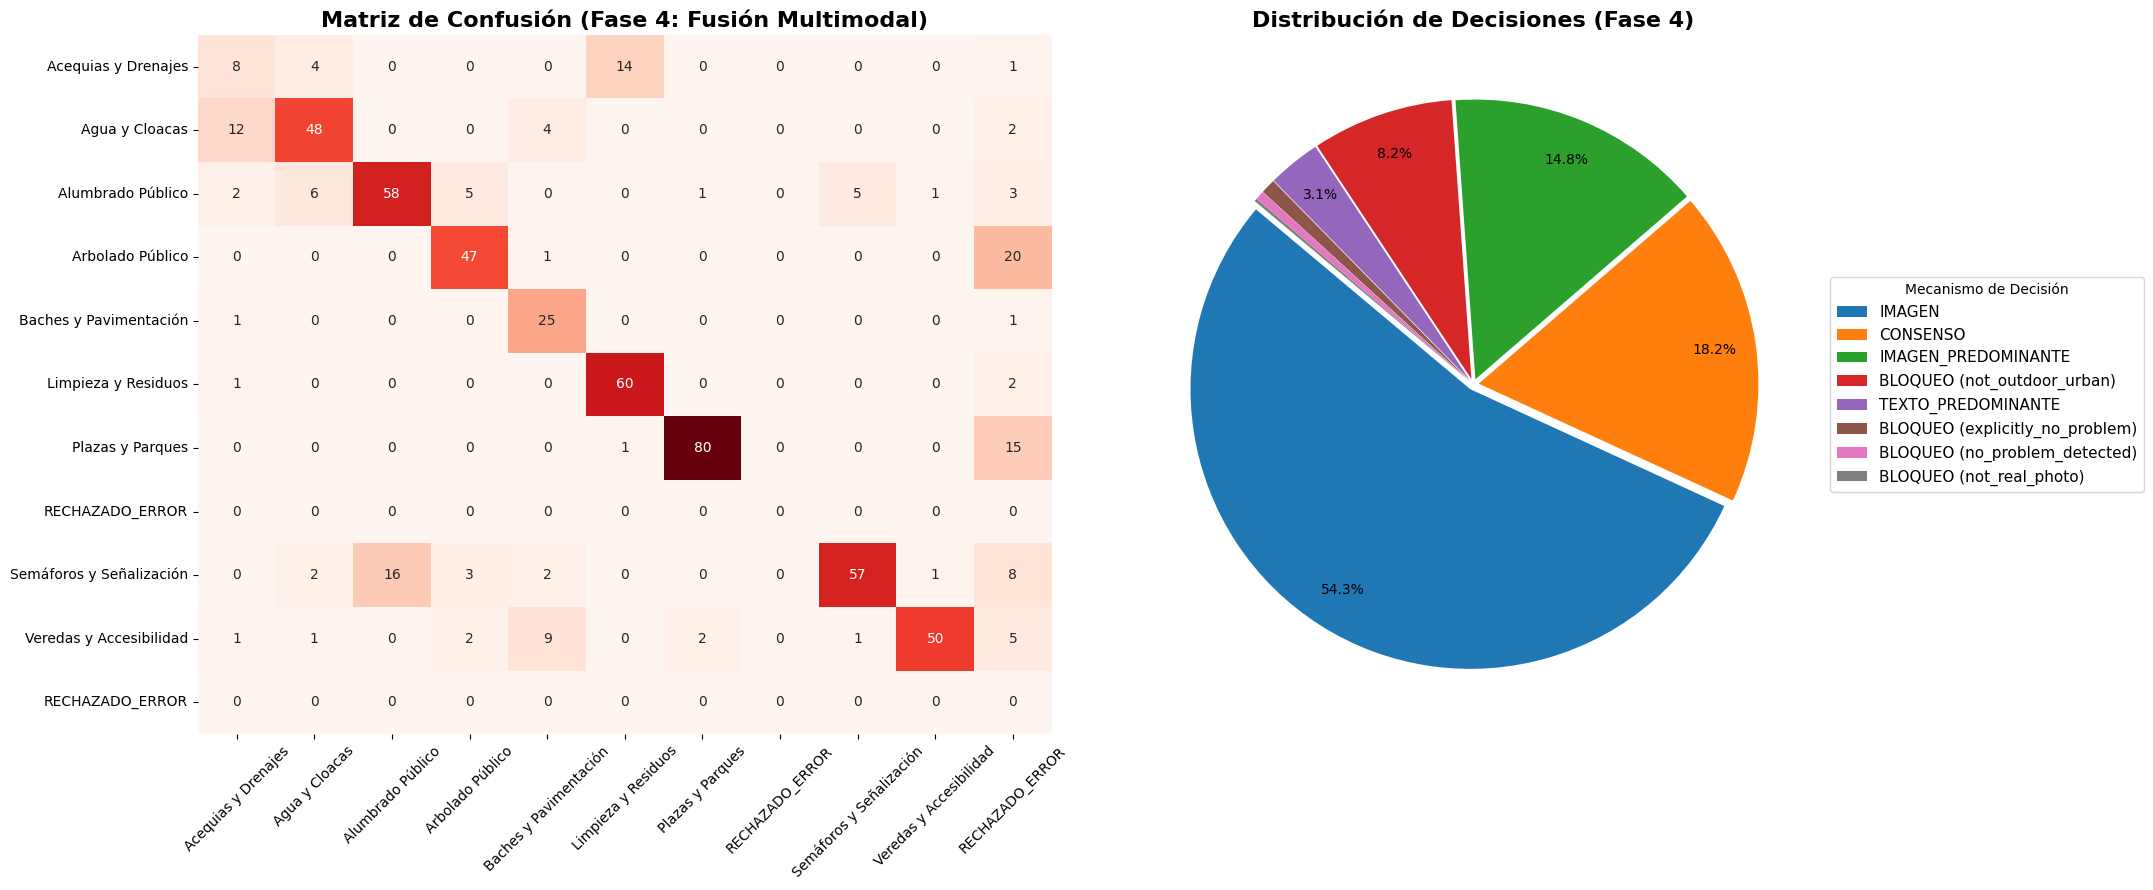

In [ ]:
# GRAFICOS
cats = sorted(set(validos["esperado"]).union(set(validos["prediccion"])))
if "RECHAZADO_ERROR" in validos["prediccion"].values:
    cats.append("RECHAZADO_ERROR")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
cm = confusion_matrix(validos["esperado"], validos["prediccion"], labels=cats)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=cats, yticklabels=cats, ax=axes[0], cbar=False)
axes[0].set_title("Matriz de Confusión (Fase 4: Fusión Multimodal)", fontsize=16, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

mecanismos = validos["mecanismo"].value_counts()
def custom_autopct(pct):
    return ('%1.1f%%' % pct) if pct > 3 else ''

wedges, texts, autotexts = axes[1].pie(
    mecanismos,
    labels=None,
    autopct=custom_autopct,
    startangle=140,
    pctdistance=0.85,
    explode=[0.02] * len(mecanismos)
)
axes[1].legend(wedges, mecanismos.index, title="Mecanismo de Decisión", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=11)
axes[1].set_title("Distribución de Decisiones (Fase 4)", fontsize=16, fontweight='bold')

plt.tight_layout()
png_path = os.path.join(BASE_DIR, 'resultados_fase4.png')
plt.savefig(png_path, dpi=300, bbox_inches='tight')
print(f'[✓] Gráfico guardado en: {png_path}')
plt.show()

In [ ]:
from IPython.display import display
print("\n==============================================")
print(" TABLA DETALLADA DE FALLOS (POR ARCHIVO)")
print("==============================================")
errores = df_res[df_res["acierto"] == False].copy()
display(errores[["image_path", "esperado", "prediccion", "mecanismo"]].sort_values(by="esperado"))


 TABLA DETALLADA DE FALLOS (POR ARCHIVO)


,image_path,esperado,prediccion,mecanismo
0,real_images/acequias/000034.jpg,Acequias y Drenajes,Limpieza y Residuos,IMAGEN
26,real_images/acequias/000066.jpg,Acequias y Drenajes,Agua y Cloacas,IMAGEN_PREDOMINANTE
23,real_images/acequias/000061.jpg,Acequias y Drenajes,Agua y Cloacas,TEXTO_PREDOMINANTE
21,real_images/acequias/000057.jpg,Acequias y Drenajes,Limpieza y Residuos,IMAGEN
20,real_images/acequias/000056.jpg,Acequias y Drenajes,Limpieza y Residuos,CONSENSO
...,...,...,...,...
644,real_images/veredas/000002.jpg,Veredas y Accesibilidad,Baches y Pavimentación,IMAGEN
643,real_images/veredas/000001.jpg,Veredas y Accesibilidad,Baches y Pavimentación,IMAGEN
710,real_images/veredas/000088.jpg,Veredas y Accesibilidad,Baches y Pavimentación,IMAGEN
671,real_images/veredas/000029.jpg,Veredas y Accesibilidad,Arbolado Público,IMAGEN


In [7]:
# ==== Estudio de ablación ====
# Objetivo: aislar el aporte de cada componente (texto, imagen, fusión) comparando variantes de decisión
# sobre el MISMO conjunto de predicciones. Para eso, se cachea la salida de CLIP y del motor de texto una
# única vez por muestra, y cada variante se construye recombinando esas mismas predicciones (sin volver a
# ejecutar los modelos), lo que también garantiza que las comparaciones pareadas (McNemar) sean válidas.
from sklearn.model_selection import train_test_split
from scipy.stats import binomtest

HARD = ["not_real_photo", "not_outdoor_urban", "inappropriate_content", "explicitly_no_problem"]
cache = []
for item in tqdm(dataset_real, desc="Cacheando features"):
    p = os.path.join(BASE_DIR, item.get("image_path", ""))
    if not os.path.exists(p):
        continue
    img = Image.open(p).convert("RGB")
    clip_res = clip_service.classify_image(img)
    ts = text_service.classify_text(item["description"])
    cache.append({"esperado": item["expected_category"], "clip": clip_res, "ts": ts,
                  "tdec": decision_service.get_best_text_category(ts)})
print(f"{len(cache)} muestras cacheadas")




Cacheando features:   0%|          | 0/714 [00:00<?, ?it/s]

Cacheando features:   0%|          | 1/714 [00:02<23:55,  2.01s/it]

Cacheando features:   0%|          | 2/714 [00:02<14:18,  1.21s/it]

Cacheando features:   0%|          | 3/714 [00:03<11:55,  1.01s/it]

Cacheando features:   1%|          | 4/714 [00:04<10:50,  1.09it/s]

Cacheando features:   1%|          | 5/714 [00:05<10:34,  1.12it/s]

Cacheando features:   1%|          | 6/714 [00:05<09:46,  1.21it/s]

Cacheando features:   1%|          | 7/714 [00:06<09:31,  1.24it/s]

Cacheando features:   1%|          | 8/714 [00:07<09:36,  1.22it/s]

Cacheando features:   1%|▏         | 9/714 [00:08<08:57,  1.31it/s]

Cacheando features:   1%|▏         | 10/714 [00:08<08:24,  1.40it/s]

Cacheando features:   2%|▏         | 11/714 [00:09<08:30,  1.38it/s]

Cacheando features:   2%|▏         | 12/714 [00:09<07:53,  1.48it/s]

Cacheando features:   2%|▏         | 13/714 [00:11<10:45,  1.09it/s]

Cacheando features:   2%|▏         |

714 muestras cacheadas


In [13]:
def predecir(c, modo, w_text=0.6):
    clip, tdec, ts = c["clip"], c["tdec"], c["ts"]
    if modo == "solo_texto":            # sin CLIP: sin filtros anti-vandalismo
        return tdec["category"] if tdec["valid"] else "RECHAZADO_ERROR"
    if modo == "solo_imagen":           # sin texto
        return clip["suggested_category"] if clip["valid"] else "RECHAZADO_ERROR"
    # Filtros de seguridad identicos a la Fase 4
    if not clip["valid"] and (clip.get("rejection_reason") in HARD or not tdec["valid"]):
        return "RECHAZADO_ERROR"
    if modo == "texto_con_gate_clip":   # CLIP solo filtra; la categoria la decide el texto
        return tdec["category"] if tdec["valid"] else clip["suggested_category"]
    if modo == "fusion":
        ds = ReportDecisionService(text_threshold=decision_service.text_threshold,
                                   text_weight=w_text, clip_weight=1 - w_text)
        f = ds.fuse_decisions(ts, clip)
        return f["category"] if f["valid"] else "RECHAZADO_ERROR"
    raise ValueError(modo)

def acierta(c, p):
    return (p == "RECHAZADO_ERROR") if c["esperado"] == "Descarte" else (p == c["esperado"])

def conteos(items, preds):
    kv = nv = kd = nd = 0
    for c, p in zip(items, preds):
        if c["esperado"] == "Descarte":
            nd += 1; kd += acierta(c, p)
        else:
            nv += 1; kv += acierta(c, p)
    return kv, nv, kd, nd

modos = ["solo_texto", "solo_imagen", "texto_con_gate_clip", "fusion"]
preds_por_modo = {m: [predecir(c, m) for c in cache] for m in modos}
filas = []
for m in modos:
    kv, nv, kd, nd = conteos(cache, preds_por_modo[m])
    filas.append({"variante": m, "accuracy validos": fmt_ci(kv, nv), "TNR descartes": fmt_ci(kd, nd)})
print("=== ABLACION (dataset completo) ===")
display(pd.DataFrame(filas))

def mcnemar(items, pa, pb, tipo):
    b = c = 0
    for it, a_, b_ in zip(items, pa, pb):
        if (it["esperado"] == "Descarte") != (tipo == "descartes"):
            continue
        oa, ob = acierta(it, a_), acierta(it, b_)
        b += (oa and not ob); c += (ob and not oa)
    p = binomtest(b, b + c, 0.5).pvalue if (b + c) else 1.0
    return b, c, p

for tipo in ["validos", "descartes"]:
    b, c, p = mcnemar(cache, preds_por_modo["fusion"], preds_por_modo["texto_con_gate_clip"], tipo)
    print(f"McNemar fusion vs texto_con_gate_clip ({tipo}): fusion-gana={b}, texto-gana={c}, p={p:.4f}")


=== ABLACION (dataset completo) ===


,variante,accuracy validos,TNR descartes
0,solo_texto,148/588 = 25.2% (IC95% 21.8-28.8%),90/126 = 71.4% (IC95% 63.0-78.6%)
1,solo_imagen,423/588 = 71.9% (IC95% 68.2-75.4%),123/126 = 97.6% (IC95% 93.2-99.2%)
2,texto_con_gate_clip,401/588 = 68.2% (IC95% 64.3-71.8%),122/126 = 96.8% (IC95% 92.1-98.8%)
3,fusion,433/588 = 73.6% (IC95% 69.9-77.0%),122/126 = 96.8% (IC95% 92.1-98.8%)


McNemar fusion vs texto_con_gate_clip (validos): fusion-gana=53, texto-gana=21, p=0.0003
McNemar fusion vs texto_con_gate_clip (descartes): fusion-gana=0, texto-gana=0, p=1.0000


In [12]:
# ==== Tuning del peso de fusion en mitad "tuning" y reporte en mitad "test" ====
# (los umbrales de CLIP quedan fijos; solo se calibra w_text.)
idx = np.arange(len(cache))
tune_idx, test_idx = train_test_split(idx, test_size=0.5, random_state=42,
                                      stratify=[c["esperado"] for c in cache])
tune = [cache[i] for i in tune_idx]; test = [cache[i] for i in test_idx]

def score_balanceado(items, w):
    kv, nv, kd, nd = conteos(items, [predecir(c, "fusion", w) for c in items])
    return 0.5 * (kv / nv + kd / nd)

grid = [round(float(w), 1) for w in np.arange(0, 1.01, 0.1)]
scores_tune = {w: score_balanceado(tune, w) for w in grid}
w_best = max(scores_tune, key=scores_tune.get)
print("Balanced accuracy (tuning) por w_text:", {w: round(s, 3) for w, s in scores_tune.items()})
print(f"w_text elegido en tuning: {w_best}")
for w in sorted({w_best, 0.6}):
    kv, nv, kd, nd = conteos(test, [predecir(c, "fusion", w) for c in test])
    print(f"TEST w_text={w}: validos {fmt_ci(kv, nv)} | descartes {fmt_ci(kd, nd)}")


Balanced accuracy (tuning) por w_text: {0.0: 0.865, 0.1: 0.868, 0.2: 0.868, 0.3: 0.866, 0.4: 0.866, 0.5: 0.868, 0.6: 0.868, 0.7: 0.863, 0.8: 0.865, 0.9: 0.846, 1.0: 0.839}
w_text elegido en tuning: 0.1
TEST w_text=0.1: validos 207/294 = 70.4%  (IC95% 65.0-75.3%) | descartes 60/63 = 95.2%  (IC95% 86.9-98.4%)
TEST w_text=0.6: validos 212/294 = 72.1%  (IC95% 66.7-76.9%) | descartes 60/63 = 95.2%  (IC95% 86.9-98.4%)


In [14]:
# ==== Desglose de desempeño por estilo de texto, nivel de ruido y contenido de imagen ====
# Complementa la ablación anterior con una prueba de McNemar de la fusión contra "solo imagen"
# (la comparación más relevante para justificar el costo de la fusión) y con tablas que muestran en
# qué subgrupos del dataset aporta o no cada componente.
assert len(cache) == len(dataset_real), "cache desalineado con dataset_real (hay imágenes omitidas)"
for c, it in zip(cache, dataset_real):
    c["text_style"] = it.get("text_style", "n/d"); c["noise_level"] = it.get("noise_level", "n/d")
    c["content_group"] = it.get("content_group", "n/d")

for otro in ["solo_imagen", "texto_con_gate_clip"]:
    for tipo in ["validos", "descartes"]:
        b, c_, p = mcnemar(cache, preds_por_modo["fusion"], preds_por_modo[otro], tipo)
        print(f"McNemar fusion vs {otro} ({tipo}): fusion-gana={b}, {otro}-gana={c_}, p={p:.4f}")

def tabla_por(campo, descartes=False):
    filas = []
    valores = sorted({c[campo] for c in cache if (c["esperado"] == "Descarte") == descartes})
    for v in valores:
        sub = [(i, c) for i, c in enumerate(cache) if (c["esperado"] == "Descarte") == descartes and c[campo] == v]
        fila = {campo: v, "n": len(sub)}
        for m in modos:
            k = sum(acierta(c, preds_por_modo[m][i]) for i, c in sub)
            fila[m] = f"{k/len(sub)*100:.1f}%"
        filas.append(fila)
    return pd.DataFrame(filas)

print("\n=== VÁLIDOS por estilo de texto ==="); display(tabla_por("text_style"))
print("=== VÁLIDOS por nivel de ruido ==="); display(tabla_por("noise_level"))
print("=== VÁLIDOS por contenido de imagen ==="); display(tabla_por("content_group"))
print("=== DESCARTES (TNR) por tipo de texto ==="); display(tabla_por("text_style", descartes=True))
print("=== DESCARTES (TNR) por tipo de imagen ==="); display(tabla_por("content_group", descartes=True))


McNemar fusion vs solo_imagen (validos): fusion-gana=14, solo_imagen-gana=4, p=0.0309
McNemar fusion vs solo_imagen (descartes): fusion-gana=0, solo_imagen-gana=1, p=1.0000
McNemar fusion vs texto_con_gate_clip (validos): fusion-gana=53, texto_con_gate_clip-gana=21, p=0.0003
McNemar fusion vs texto_con_gate_clip (descartes): fusion-gana=0, texto_con_gate_clip-gana=0, p=1.0000

=== VÁLIDOS por estilo de texto ===


,text_style,n,solo_texto,solo_imagen,texto_con_gate_clip,fusion
0,claro,192,50.5%,74.0%,72.9%,77.6%
1,formal,91,27.5%,67.0%,70.3%,70.3%
2,indirecto,222,11.3%,73.9%,63.5%,73.9%
3,vago,83,1.2%,67.5%,67.5%,67.5%


=== VÁLIDOS por nivel de ruido ===


,noise_level,n,solo_texto,solo_imagen,texto_con_gate_clip,fusion
0,fuerte,87,21.8%,65.5%,63.2%,65.5%
1,leve,103,24.3%,78.6%,71.8%,77.7%
2,medio,81,22.2%,80.2%,65.4%,80.2%
3,ninguno,317,27.1%,69.4%,69.1%,72.9%


=== VÁLIDOS por contenido de imagen ===


,content_group,n,solo_texto,solo_imagen,texto_con_gate_clip,fusion
0,acequias,27,18.5%,29.6%,33.3%,29.6%
1,alumbrado,81,16.0%,72.8%,59.3%,71.6%
2,arbolado,68,30.9%,69.1%,61.8%,69.1%
3,baches,27,22.2%,92.6%,59.3%,92.6%
4,cloacas,66,68.2%,60.6%,78.8%,72.7%
5,limpieza,63,27.0%,93.7%,90.5%,95.2%
6,plazas_bancos,34,5.9%,85.3%,79.4%,85.3%
7,plazas_juegos,62,1.6%,82.3%,79.0%,82.3%
8,semaforos_carteles,32,6.2%,78.1%,65.6%,71.9%
9,semaforos_semaforo,57,43.9%,54.4%,71.9%,59.6%


=== DESCARTES (TNR) por tipo de texto ===


,text_style,n,solo_texto,solo_imagen,texto_con_gate_clip,fusion
0,irrelevante,23,95.7%,100.0%,100.0%,100.0%
1,trampa_claro,35,54.3%,100.0%,97.1%,97.1%
2,trampa_indirecto,48,66.7%,93.8%,93.8%,93.8%
3,vago,20,85.0%,100.0%,100.0%,100.0%


=== DESCARTES (TNR) por tipo de imagen ===


,content_group,n,solo_texto,solo_imagen,texto_con_gate_clip,fusion
0,desc_calle_sin_problema,31,67.7%,90.3%,87.1%,87.1%
1,desc_interior,33,75.8%,100.0%,100.0%,100.0%
2,desc_montana,29,65.5%,100.0%,100.0%,100.0%
3,desc_perros,33,75.8%,100.0%,100.0%,100.0%
